In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
dataset = pd.read_csv("covid19_Confirmed_dataset.csv")
dataset.head(5)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,33.0000,65.0000,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
3,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
4,NaN,Angola,-11.2027,17.8739,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


In [4]:
dataset.shape

(266, 104)

In [18]:
df = dataset.drop(["Lat","Long"], axis = 1, inplace = True)

In [8]:
dataset

,Province/State,Country/Region,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,0,0,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
1,NaN,Albania,0,0,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
2,NaN,Algeria,0,0,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
3,NaN,Andorra,0,0,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
4,NaN,Angola,0,0,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,NaN,Western Sahara,0,0,0,0,0,0,0,0,...,6,6,6,6,6,6,6,6,6,6
262,NaN,Sao Tome and Principe,0,0,0,0,0,0,0,0,...,4,4,4,4,4,4,4,8,8,14
263,NaN,Yemen,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,6,6
264,NaN,Comoros,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [10]:
corona_dataset_aggregated = dataset.groupby("Country/Region").sum()

In [11]:
corona_dataset_aggregated.head(6)

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
Albania,0,0,0,0,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
Algeria,0,0,0,0,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
Andorra,0,0,0,0,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
Angola,0,0,0,0,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27
Antigua and Barbuda,0,0,0,0,0,0,0,0,0,0,...,23,24,24,24,24,24,24,24,24,24


In [12]:
corona_dataset_aggregated.shape

(187, 100)

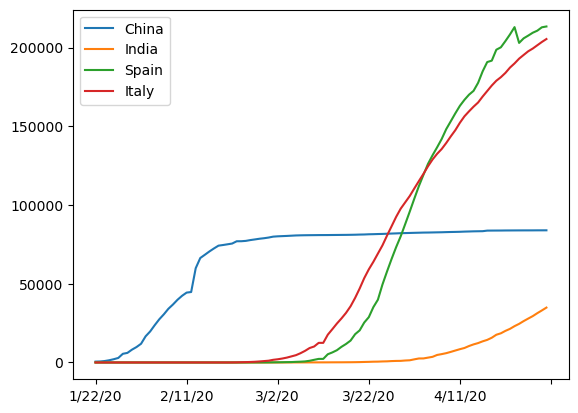

In [20]:
corona_dataset_aggregated.loc["China"].plot();
corona_dataset_aggregated.loc["India"].plot();
corona_dataset_aggregated.loc["Spain"].plot();
corona_dataset_aggregated.loc["Italy"].plot();
plt.legend();

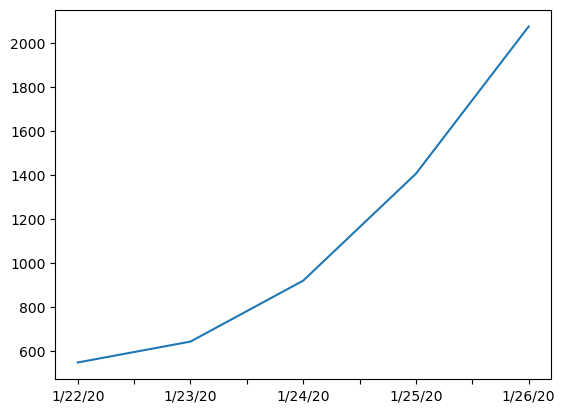

In [21]:
corona_dataset_aggregated.loc["China"][:5].plot();

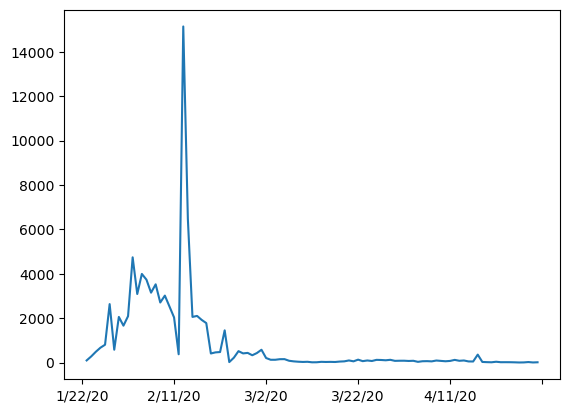

In [23]:
#Calculating first derivative
corona_dataset_aggregated.loc["China"].diff().plot();

In [27]:
corona_dataset_aggregated.loc["China"].diff().max()

15136.0

In [28]:
corona_dataset_aggregated.loc["Spain"].diff().max()

9630.0

In [29]:
corona_dataset_aggregated.loc["India"].diff().max()

1893.0

In [30]:
corona_dataset_aggregated.loc["Italy"].diff().max()

6557.0

In [35]:
countries = list(corona_dataset_aggregated.index)
max_infection_rates = []

for c in countries:
    max_infection_rates.append(corona_dataset_aggregated.loc[c].diff().max())
corona_dataset_aggregated["Max_infection_rates"] = max_infection_rates

In [36]:
corona_dataset_aggregated

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,Max_infection_rates
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,1176,1279,1351,1463,1531,1703,1828,1939,2171,232.0
Albania,0,0,0,0,0,0,0,0,0,0,...,634,663,678,712,726,736,750,766,773,34.0
Algeria,0,0,0,0,0,0,0,0,0,0,...,2910,3007,3127,3256,3382,3517,3649,3848,4006,199.0
Andorra,0,0,0,0,0,0,0,0,0,0,...,723,723,731,738,738,743,743,743,745,43.0
Angola,0,0,0,0,0,0,0,0,0,0,...,25,25,25,25,26,27,27,27,27,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
West Bank and Gaza,0,0,0,0,0,0,0,0,0,0,...,474,480,484,342,342,342,343,344,344,66.0
Western Sahara,0,0,0,0,0,0,0,0,0,0,...,6,6,6,6,6,6,6,6,6,4.0
Yemen,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,6,6,5.0


In [37]:
corona_data = pd.DataFrame(corona_dataset_aggregated["Max_infection_rates"])

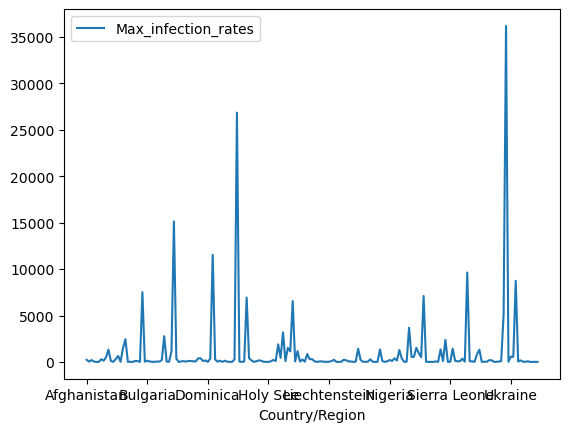

In [39]:
corona_data.plot();

In [40]:
corona_data

,Max_infection_rates
Country/Region,
Afghanistan,232.0
Albania,34.0
Algeria,199.0
Andorra,43.0
Angola,5.0
...,...
West Bank and Gaza,66.0
Western Sahara,4.0
Yemen,5.0


In [61]:
#Importing 2nd database
happiness_report = pd.read_csv("2015.csv")

In [62]:
happiness_report

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176
...,...,...,...,...,...,...,...,...,...,...,...,...
153,Rwanda,Sub-Saharan Africa,154,3.465,0.03464,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042
154,Benin,Sub-Saharan Africa,155,3.340,0.03656,0.28665,0.35386,0.31910,0.48450,0.08010,0.18260,1.63328
155,Syria,Middle East and Northern Africa,156,3.006,0.05015,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
156,Burundi,Sub-Saharan Africa,157,2.905,0.08658,0.01530,0.41587,0.22396,0.11850,0.10062,0.19727,1.83302


In [63]:
happiness_report.head(10)

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176
5,Finland,Western Europe,6,7.406,0.03140,1.29025,1.31826,0.88911,0.64169,0.41372,0.23351,2.61955
6,Netherlands,Western Europe,7,7.378,0.02799,1.32944,1.28017,0.89284,0.61576,0.31814,0.47610,2.46570
7,Sweden,Western Europe,8,7.364,0.03157,1.33171,1.28907,0.91087,0.65980,0.43844,0.36262,2.37119
8,New Zealand,Australia and New Zealand,9,7.286,0.03371,1.25018,1.31967,0.90837,0.63938,0.42922,0.47501,2.26425
9,Australia,Australia and New Zealand,10,7.284,0.04083,1.33358,1.30923,0.93156,0.65124,0.35637,0.43562,2.26646


In [64]:
useless_columns = ["Happiness Rank","Standard Error","Generosity","Region","Dystopia Residual"]

In [65]:
happiness_report.drop(useless_columns, axis = 1, inplace = True)

In [66]:
happiness_report 

,Country,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption)
0,Switzerland,7.587,1.39651,1.34951,0.94143,0.66557,0.41978
1,Iceland,7.561,1.30232,1.40223,0.94784,0.62877,0.14145
2,Denmark,7.527,1.32548,1.36058,0.87464,0.64938,0.48357
3,Norway,7.522,1.45900,1.33095,0.88521,0.66973,0.36503
4,Canada,7.427,1.32629,1.32261,0.90563,0.63297,0.32957
...,...,...,...,...,...,...,...
153,Rwanda,3.465,0.22208,0.77370,0.42864,0.59201,0.55191
154,Benin,3.340,0.28665,0.35386,0.31910,0.48450,0.08010
155,Syria,3.006,0.66320,0.47489,0.72193,0.15684,0.18906
156,Burundi,2.905,0.01530,0.41587,0.22396,0.11850,0.10062


In [72]:
corona_data.shape

(187, 1)

In [73]:
happiness_report.shape

(158, 6)

In [74]:
data = corona_data.join(happiness_report, how = "inner")
data

,Max_infection_rates,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption)
Afghanistan,232.0,3.575,0.31982,0.30285,0.30335,0.23414,0.09719
Albania,34.0,4.959,0.87867,0.80434,0.81325,0.35733,0.06413
Algeria,199.0,5.605,0.93929,1.07772,0.61766,0.28579,0.17383
Angola,5.0,4.033,0.75778,0.86040,0.16683,0.10384,0.07122
Argentina,291.0,6.574,1.05351,1.24823,0.78723,0.44974,0.08484
...,...,...,...,...,...,...,...
Venezuela,29.0,6.810,1.04424,1.25596,0.72052,0.42908,0.11069
Vietnam,19.0,5.360,0.63216,0.91226,0.74676,0.59444,0.10441
Yemen,5.0,4.077,0.54649,0.68093,0.40064,0.35571,0.07854
Zambia,9.0,5.129,0.47038,0.91612,0.29924,0.48827,0.12468


In [75]:
data.corr()

,Max_infection_rates,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption)
Max_infection_rates,1.000000,0.227333,0.235445,0.176345,0.286783,0.110988,0.047062
Happiness Score,0.227333,1.000000,0.782725,0.740520,0.738470,0.580437,0.436289
Economy (GDP per Capita),0.235445,0.782725,1.000000,0.651997,0.822992,0.373916,0.357078
Family,0.176345,0.740520,0.651997,1.000000,0.560885,0.448943,0.220285
Health (Life Expectancy),0.286783,0.738470,0.822992,0.560885,1.000000,0.368250,0.280663
Freedom,0.110988,0.580437,0.373916,0.448943,0.368250,1.000000,0.491964
Trust (Government Corruption),0.047062,0.436289,0.357078,0.220285,0.280663,0.491964,1.000000


C:\Users\XINSlim3\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


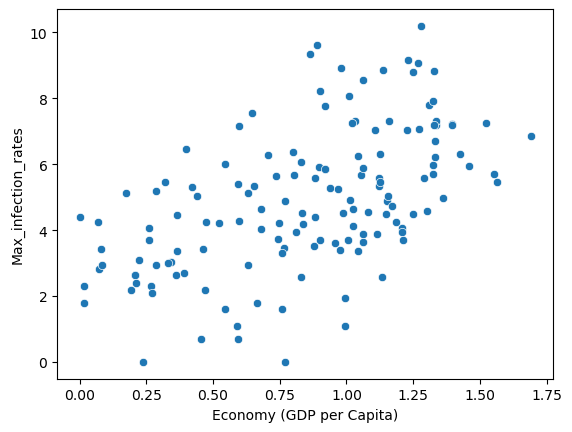

In [84]:
y = data["Max_infection_rates"]
x = data["Economy (GDP per Capita)"]
sns.scatterplot(x,np.log(y)); #logscaling

C:\Users\XINSlim3\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


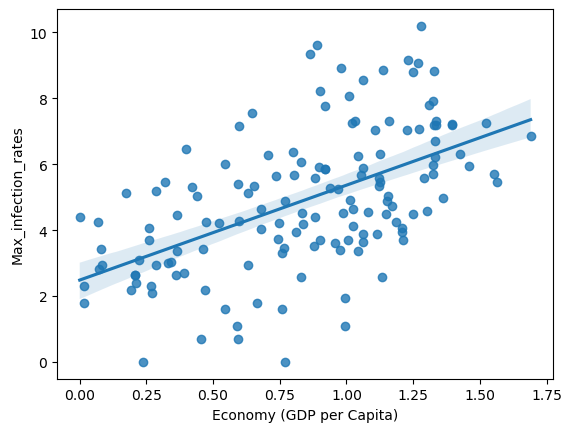

In [85]:
sns.regplot(x,np.log(y)); 

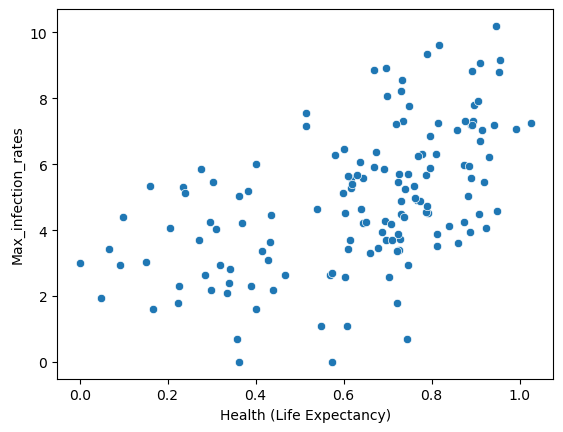

In [86]:
y = data["Max_infection_rates"]
x = data["Health (Life Expectancy)"]
sns.scatterplot(x,np.log(y));

C:\Users\XINSlim3\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


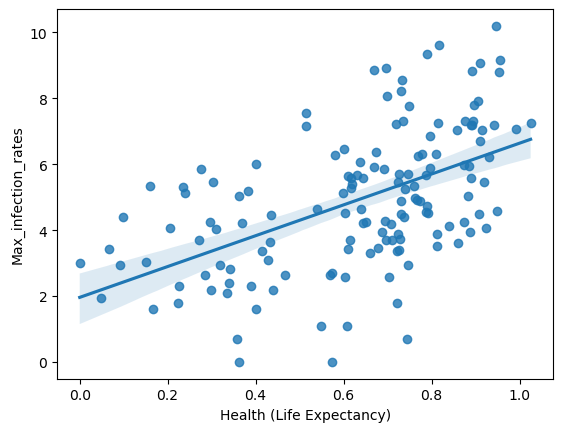

In [87]:
sns.regplot(x,np.log(y));

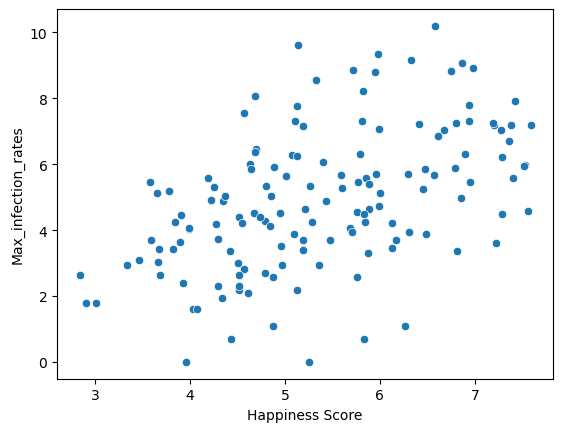

In [88]:
y = data["Max_infection_rates"]
x = data["Happiness Score"]
sns.scatterplot(x,np.log(y));

C:\Users\XINSlim3\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


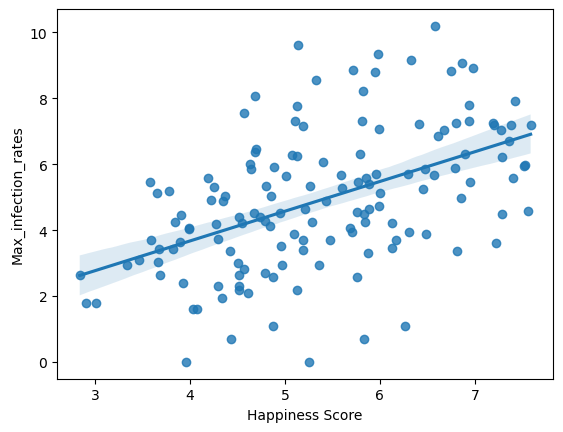

In [91]:
sns.regplot(x,np.log(y));

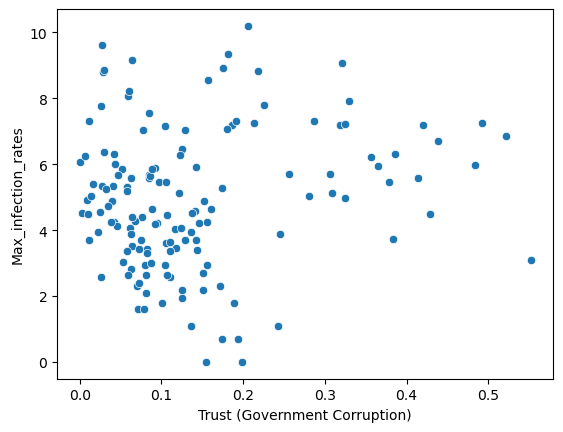

In [92]:
y = data["Max_infection_rates"]
x = data["Trust (Government Corruption)"]
sns.scatterplot(x,np.log(y));

C:\Users\XINSlim3\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


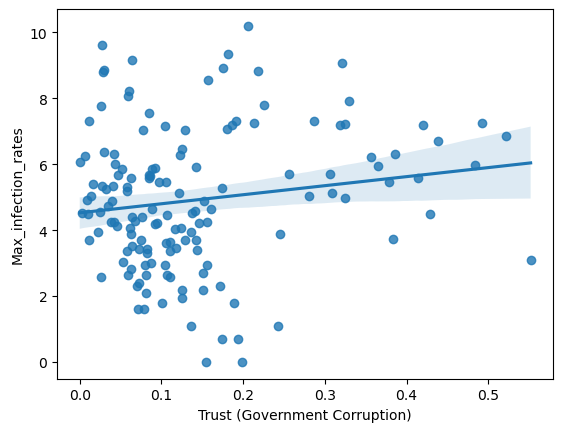

In [93]:
sns.regplot(x,np.log(y));